In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 140)

DATA_PATH = 'luckyscent_data/luckyscent_fragrances.csv'

# Luckyscent EDA

In deze notebook verkennen we de dataset in `luckyscent_data/luckyscent_fragrances.csv`.

Doelen:
- structuur en datakwaliteit controleren
- kernverdelingen bekijken (gender, concentration, brand, country)
- prijs- en jaartalvelden opschonen en analyseren
- meest voorkomende `notes` en `style` tags identificeren

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head()

Rows: 3,353 | Columns: 11


,name,brand,concentration,gender,country,released,price,notes,style,description,url
0,Fragrance Fitting - Custom Sample Pack,Brands,NaN,NaN,NaN,NaN,$,NaN,NaN,"Let us help you find your next signature scent! The Luckyscent Fragrance FittingÂ®is a selection of six samples, carefully handpicked fo...",https://www.luckyscent.com/products/fragrance-fitting
1,Kun Amo,Brands,Extrait,Unisex,France,2025.0,$,"Mandarin, Bergamot, Almond, Crunchy Pear, Jasmine, Sea Spray, Raspberry, Cedarwood, Sugar, White Musks, Ambery Woods, Cashmeran","Floral - Fruity, Fruity, Powdery / Soft, Sweet, Woody - Amber",Jeroboam,https://www.luckyscent.com/products/kun-amo-by-jeroboam
2,Mango Sticky Rice,Brands,Eau de Parfum,Unisex,NaN,2026.0,$,"Ripe Mango, Sticky Rice, Coconut Milk","Creamy, Fruity, Gourmand, Milky, Sweet, Tropical / Beachy",French Cowboy,https://www.luckyscent.com/products/mango-sticky-rice-by-dannam
3,Dandelion Butter,Brands,NaN,Unisex,United States,2025.0,$?,"Pollen, Dandelion Greens, Yellow Dandelion, Snapped Stem, Milky Sap, Salted Butter, Dandelion-stained Chin","Floral, Floral - Light, Green / Herbaceous, Milky, Unusual / Unexpected, Warm","The boundlessly creative noses behind Clue draw fragrant inspiration from every nostalgic and evocative aspect of the American midwest, ...",https://www.luckyscent.com/products/dandelion-butter-by-clue
4,White Rice,Brands,Eau de Parfum,Unisex,Vietnam,2023.0,$,"Rice, Pandan, Orris, Jasmine, White Musk, Cedarwood, Tonka Bean","Creamy, Floral - Light, Gourmand, Milky, Powdery / Soft, Skin Scent / Minimal",d'Annam,https://www.luckyscent.com/products/white-rice-by-dannam


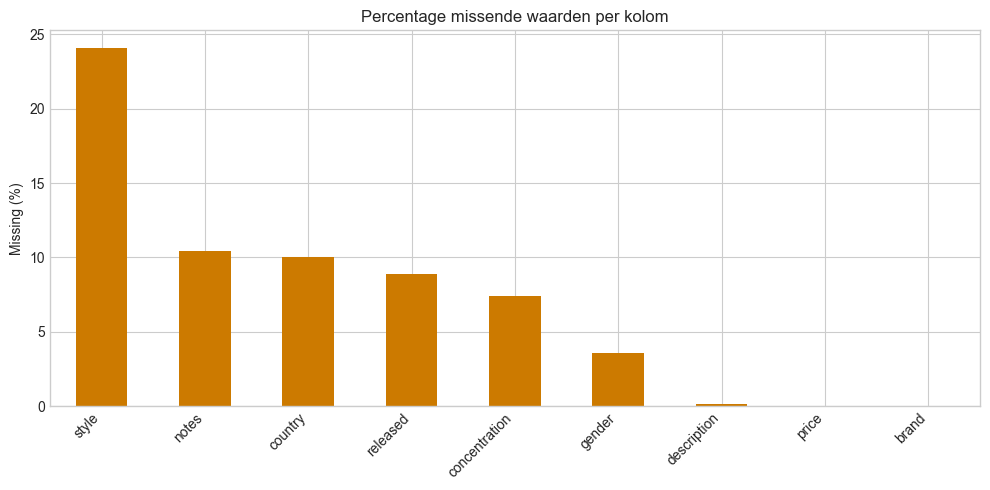

In [3]:
# Missing values visualiseren
base_missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
base_missing_pct = base_missing_pct[base_missing_pct > 0]

plt.figure(figsize=(10, 5))
base_missing_pct.plot(kind='bar', color='#cc7a00')
plt.title('Percentage missende waarden per kolom')
plt.ylabel('Missing (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
# Hulpkolommen voor EDA
eda = df.copy()

# Released als numeriek jaar
eda['released_year'] = pd.to_numeric(eda['released'], errors='coerce')

# Price normaliseren: $, $?, lege of onbekende prijs -> NaN, anders numeriek
price_str = (
    eda['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace('?', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
eda['price_num'] = pd.to_numeric(price_str, errors='coerce')

# Description lengte voor een simpele tekstfeature
eda['description_len'] = eda['description'].fillna('').str.len()

eda[['released', 'released_year', 'price', 'price_num', 'description_len']].head()

,released,released_year,price,price_num,description_len
0,NaN,NaN,$,NaN,258
1,2025.0,2025.0,$,NaN,8
2,2026.0,2026.0,$,NaN,13
3,2025.0,2025.0,$?,NaN,918
4,2023.0,2023.0,$,NaN,7


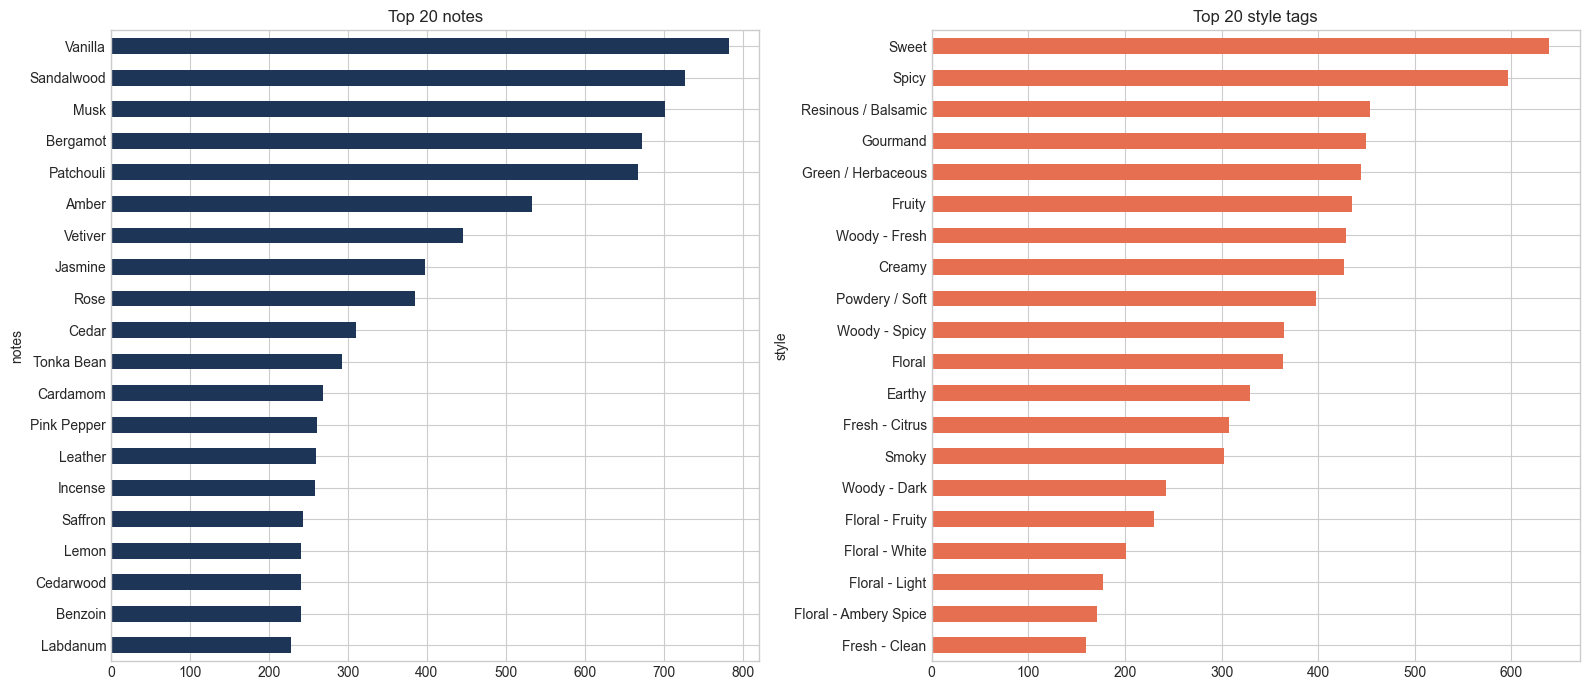

,top_notes,top_styles
Amber,533.0,NaN
Bergamot,673.0,NaN
Cedar,310.0,NaN
Creamy,NaN,427.0
Fruity,NaN,435.0
Gourmand,NaN,449.0
Green / Herbaceous,NaN,444.0
Jasmine,397.0,NaN
Musk,701.0,NaN
Patchouli,667.0,NaN


In [10]:
# Notes en styles exploderen voor frequentie-analyse
notes_long = (
    eda['notes']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)

styles_long = (
    eda['style']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)

top_notes = notes_long.value_counts().head(20)
top_styles = styles_long.value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_notes.sort_values().plot(kind='barh', ax=axes[0], color='#1d3557')
axes[0].set_title('Top 20 notes')

top_styles.sort_values().plot(kind='barh', ax=axes[1], color='#e76f51')
axes[1].set_title('Top 20 style tags')

plt.tight_layout()
plt.show()

pd.DataFrame({'top_notes': top_notes.head(10), 'top_styles': top_styles.head(10)})

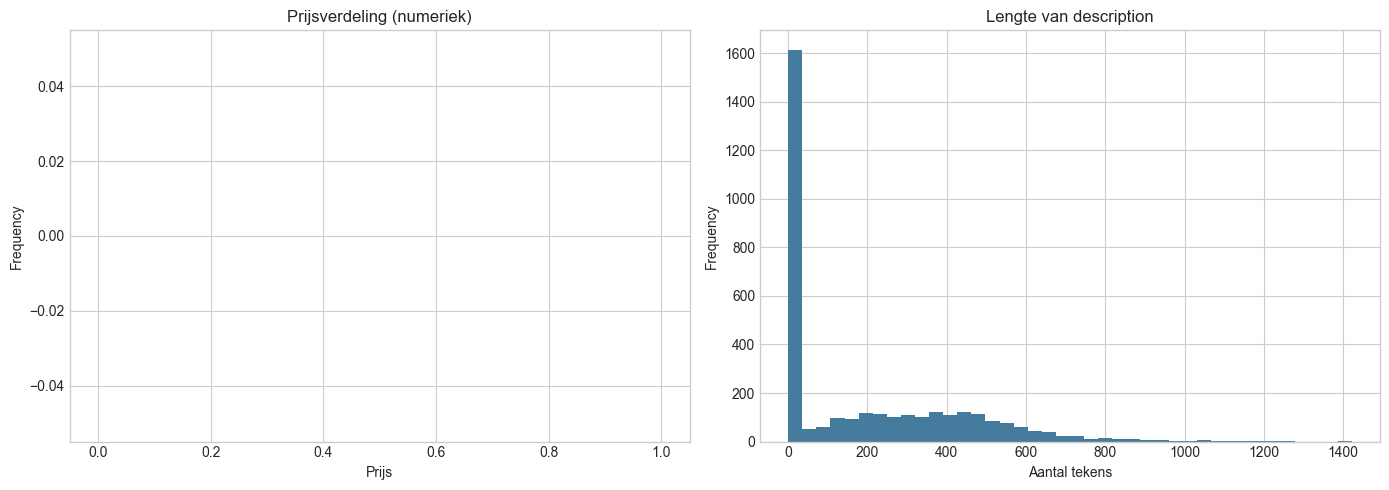

,count,mean,std,min,25%,50%,75%,max
price_num,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description_len,3353.0,202.715479,235.549418,0.0,13.0,79.0,374.0,1422.0


In [11]:
# Price en description lengte
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

eda['price_num'].dropna().plot(kind='hist', bins=30, ax=axes[0], color='#bc6c25')
axes[0].set_title('Prijsverdeling (numeriek)')
axes[0].set_xlabel('Prijs')

eda['description_len'].plot(kind='hist', bins=40, ax=axes[1], color='#457b9d')
axes[1].set_title('Lengte van description')
axes[1].set_xlabel('Aantal tekens')

plt.tight_layout()
plt.show()

eda[['price_num', 'description_len']].describe().T

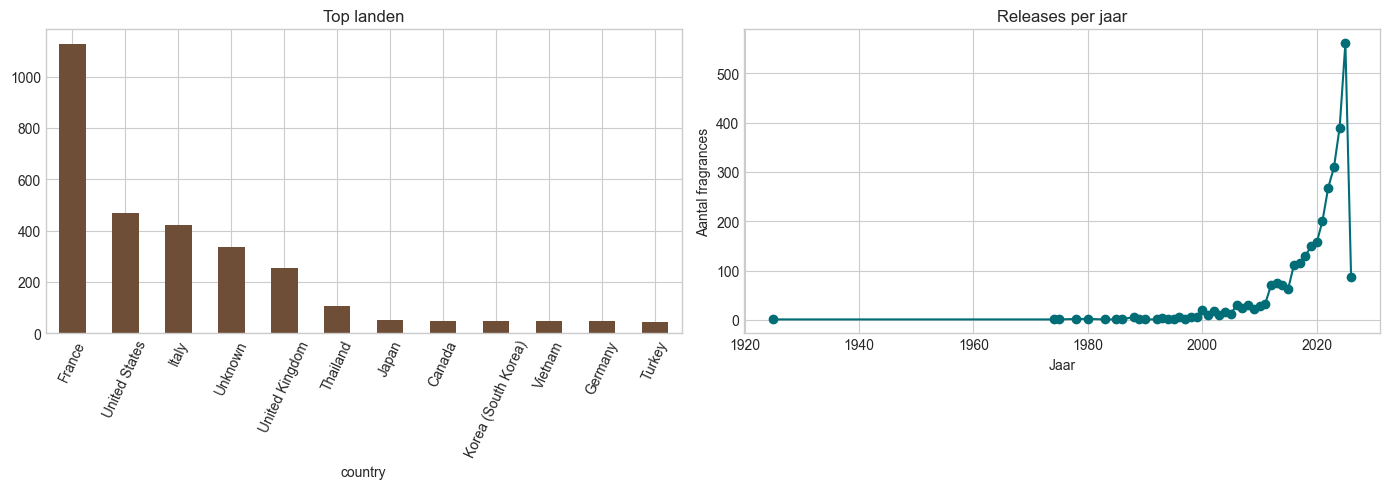

In [12]:
# Country en released year
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

eda['country'].fillna('Unknown').value_counts().head(12).plot(kind='bar', ax=axes[0], color='#6f4e37')
axes[0].set_title('Top landen')
axes[0].tick_params(axis='x', rotation=65)

eda['released_year'].dropna().astype(int).value_counts().sort_index().plot(kind='line', marker='o', ax=axes[1], color='#006d77')
axes[1].set_title('Releases per jaar')
axes[1].set_xlabel('Jaar')
axes[1].set_ylabel('Aantal fragrances')

plt.tight_layout()
plt.show()

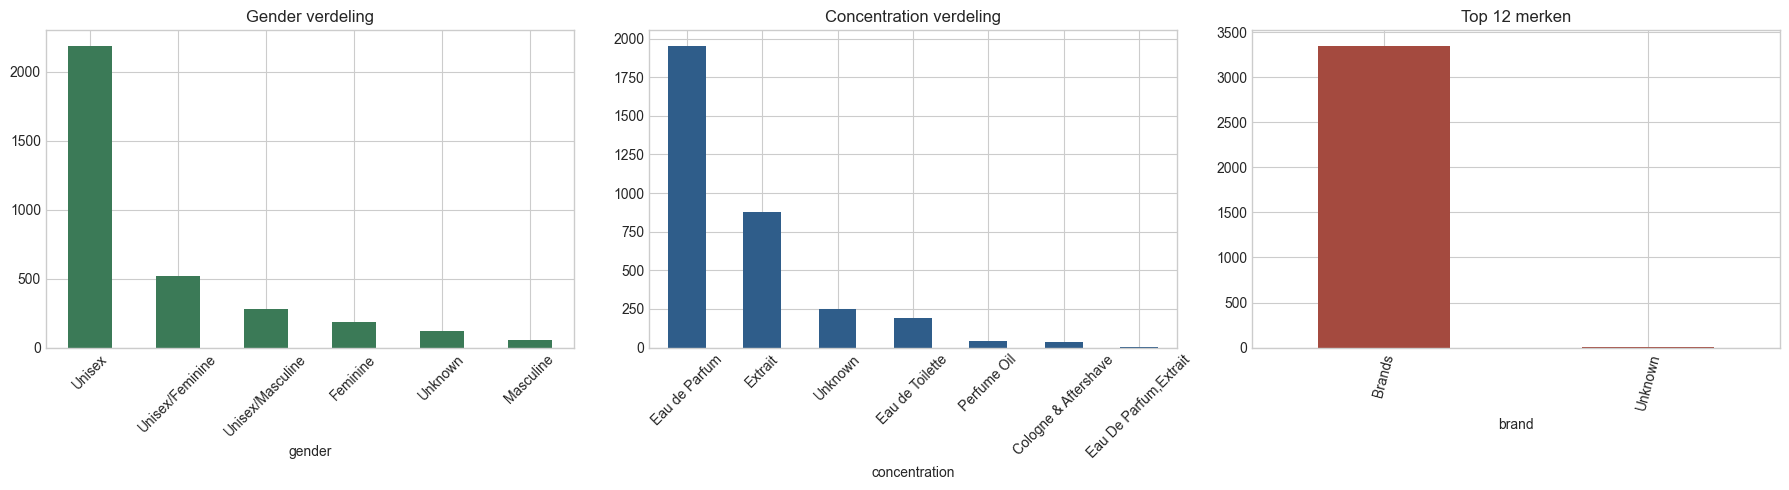

In [9]:
# Distributies: gender, concentration, top brands
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

eda['gender'].fillna('Unknown').value_counts().head(8).plot(kind='bar', ax=axes[0], color='#3b7a57')
axes[0].set_title('Gender verdeling')
axes[0].tick_params(axis='x', rotation=45)

eda['concentration'].fillna('Unknown').value_counts().head(10).plot(kind='bar', ax=axes[1], color='#2f5d8a')
axes[1].set_title('Concentration verdeling')
axes[1].tick_params(axis='x', rotation=45)

eda['brand'].fillna('Unknown').value_counts().head(12).plot(kind='bar', ax=axes[2], color='#a44a3f')
axes[2].set_title('Top 12 merken')
axes[2].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

## Snelle conclusies

- De kolom `brand` bevat bijna overal de waarde `Brands`; dit wijst op een scraping/parsing-issue.
- De kolom `price` bevat vooral `$` of `$?`, dus er zijn praktisch geen numerieke prijzen beschikbaar.
- `style`, `notes`, `country`, `released` en `concentration` hebben missende waarden.
- Notes en styles geven wel bruikbare signalen over geurprofielen (bijv. Vanilla, Sandalwood, Sweet, Spicy).

## Volgende stap 

- Verbeter de scraper zodat echte merknaam en numerieke prijs apart worden opgeslagen.